In [ ]:

# !pip install pandas numpy scikit-learn
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
import pathlib


In [ ]:

model_dir = pathlib.Path.cwd().parent
MODEL_PATH = model_dir / "models"
data_dir = model_dir / "datasets"
df = pd.read_csv(data_dir / "donor_snapshots_with_targets.csv")
df = pd.read_csv(data_dir / "synthetic_bloodbank_daily.csv")
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["date", "hospital", "blood_type"]).reset_index(drop=True)
df.head(-5)


,date,hospital,dow,weekend,month,holiday,temp_c,rain_mm,flu_index,trauma_cases,...,blood_type,stock_start,units_collected,units_used,wastage,stock_end,critical_stock,stockout_next_day,heavy_demand,heavy_demand_next_day
0,2023-01-01,Central,6,1,1,1,17.537652,7.846072,0.443917,10,...,A+,67,3,11,1,58,0,0,1,0
1,2023-01-01,Central,6,1,1,1,17.537652,7.846072,0.443917,10,...,A-,56,1,6,1,50,0,0,0,1
2,2023-01-01,Central,6,1,1,1,17.537652,7.846072,0.443917,10,...,AB+,42,4,4,0,42,0,0,0,0
3,2023-01-01,Central,6,1,1,1,17.537652,7.846072,0.443917,10,...,AB-,48,0,3,0,45,0,0,1,0
4,2023-01-01,Central,6,1,1,1,17.537652,7.846072,0.443917,10,...,B+,69,4,8,0,65,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23382,2024-12-31,North,1,0,12,0,23.106802,15.150342,0.718925,8,...,O+,0,2,6,0,0,1,1,0,0
23383,2024-12-31,North,1,0,12,0,23.106802,15.150342,0.718925,8,...,O-,0,3,7,0,0,1,1,0,0
23384,2024-12-31,West,1,0,12,0,18.963887,1.016330,0.500318,6,...,A+,0,4,10,0,0,1,1,1,0
23385,2024-12-31,West,1,0,12,0,18.963887,1.016330,0.500318,6,...,A-,2,1,6,0,0,1,1,1,0


In [ ]:

# ----------------------------
# Feature engineering
# ----------------------------
# Create lag features (yesterday stock & usage) to make next-day prediction realistic
df = df.sort_values(["hospital", "blood_type", "date"]).reset_index(drop=True)
grp = df.groupby(["hospital", "blood_type"])

df["stock_end_lag1"] = grp["stock_end"].shift(1)
df["units_used_lag1"] = grp["units_used"].shift(1)
df["units_collected_lag1"] = grp["units_collected"].shift(1)

# Rolling averages (last 7 days)
# Rolling averages (last 7 days) within each (hospital, blood_type)
df["used_ma7"] = grp["units_used"].transform(lambda s: s.shift(1).rolling(7, min_periods=1).mean())
df["collect_ma7"] = grp["units_collected"].transform(lambda s: s.shift(1).rolling(7, min_periods=1).mean())


# Calendar features
df["dayofyear"] = df["date"].dt.dayofyear
df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)

# Drop first rows that don't have lags
model_df = df.dropna(subset=["stock_end_lag1", "units_used_lag1", "units_collected_lag1", "used_ma7", "collect_ma7"]).copy()
print("Usable rows after lags:", len(model_df))

model_df.head()


Usable rows after lags: 23360


,date,hospital,dow,weekend,month,holiday,temp_c,rain_mm,flu_index,trauma_cases,...,stockout_next_day,heavy_demand,heavy_demand_next_day,stock_end_lag1,units_used_lag1,units_collected_lag1,used_ma7,collect_ma7,dayofyear,weekofyear
1,2023-01-02,Central,0,0,1,0,20.150370,3.521402,0.697803,4,...,0,0,0,58.0,11.0,3.0,11.000000,3.000000,2,1
2,2023-01-03,Central,1,0,1,0,19.396637,2.506452,0.649278,3,...,0,0,0,57.0,6.0,5.0,8.500000,4.000000,3,1
3,2023-01-04,Central,2,0,1,0,17.622055,6.685825,0.618573,4,...,0,0,0,55.0,8.0,6.0,8.333333,4.666667,4,1
4,2023-01-05,Central,3,0,1,0,17.044359,3.075571,0.548890,2,...,0,0,0,53.0,8.0,6.0,8.250000,5.000000,5,1
5,2023-01-06,Central,4,0,1,0,21.231134,6.916750,0.663468,2,...,0,0,0,49.0,6.0,4.0,7.800000,4.800000,6,1


In [ ]:

# ----------------------------
# Choose target
# ----------------------------
TARGET = "stockout_next_day"   # change to "heavy_demand_next_day" to train the other model

y = model_df[TARGET].astype(int)

# Features to use
feature_cols = [
    # identifiers/categoricals
    "hospital", "blood_type",

    # calendar
    "dow", "weekend", "month", "holiday", "dayofyear", "weekofyear",

    # context
    "temp_c", "rain_mm", "flu_index", "trauma_cases", "scheduled_surgeries",
    "donation_campaign", "supply_shock",

    # stock / flows
    "stock_start", "stock_end", "wastage",
    "units_used", "units_collected",

    # lags / rolling
    "stock_end_lag1", "units_used_lag1", "units_collected_lag1",
    "used_ma7", "collect_ma7",
]

X = model_df[feature_cols]

cat_cols = ["hospital", "blood_type"]
num_cols = [c for c in feature_cols if c not in cat_cols]

print("Positive rate:", y.mean())


Positive rate: 0.5516267123287671


In [ ]:

# ----------------------------
# Time-based train/test split
# ----------------------------
# Use last 20% of dates as test
cutoff = model_df["date"].quantile(0.80)
train_idx = model_df["date"] <= cutoff
test_idx  = model_df["date"] > cutoff

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train positive rate:", y_train.mean(), " Test positive rate:", y_test.mean())

# Guard against the classic predict_proba error (only one class in training)
if y_train.nunique() < 2:
    raise ValueError(
        f"Training split has only one class for target={TARGET}. "
        "Regenerate data or change cutoff/target."
    )


Train: (18688, 25)  Test: (4672, 25)
Train positive rate: 0.5481057363013698  Test positive rate: 0.5657106164383562


In [ ]:

# ----------------------------
# Pipeline (preprocess + model)
# ----------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
    ],
    remainder="drop"
)

clf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    max_depth=None,
    min_samples_leaf=2
)

model = Pipeline(steps=[
    ("prep", preprocess),
    ("rf", clf)
])

model


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['hospital', 'blood_type']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['dow', 'weekend', 'month',
                                                   'holiday', 'dayofyear',
                                                   'weekofyear', 'temp_c',
                                                   '...
                                                   'trauma_cases',
                                                   'scheduled_surgeries',
                                                   'donation_campaign',
                                                   'supply_shock',
                                                   'stock_start', 'stock_end',
                                                   'wastage', 'units_used',
                                                   'units_collected',
                                                   'stock_end_lag1',
                                                   'units_used_lag1',
                                                   'units_collected_lag1',
                                                   'used_ma7',
                                                   'collect_ma7'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        min_samples_leaf=2, n_estimators=500,
                                        n_jobs=-1, random_state=42))])

In [ ]:

# ----------------------------
# Train
# ----------------------------
model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ROC AUC:", roc_auc_score(y_test, proba))
print("PR AUC :", average_precision_score(y_test, proba))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred, digits=3))


ROC AUC: 0.8806928742466174
PR AUC : 0.8763822275878137

Confusion matrix:
 [[1397  632]
 [ 183 2460]]

Report:
               precision    recall  f1-score   support

           0      0.884     0.689     0.774      2029
           1      0.796     0.931     0.858      2643

    accuracy                          0.826      4672
   macro avg      0.840     0.810     0.816      4672
weighted avg      0.834     0.826     0.822      4672



In [ ]:
# !pip install xgboost

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# --- handle class imbalance (recommended) ---
pos = int(y_train.sum())
neg = int((y_train == 0).sum())
scale_pos_weight = (neg / max(pos, 1))

xgb = XGBClassifier(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="aucpr",          # good for imbalanced
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

model_xgb = Pipeline(steps=[
    ("prep", preprocess),
    ("xgb", xgb)
])

# train
model_xgb.fit(X_train, y_train)

# predict
proba_xgb = model_xgb.predict_proba(X_test)[:, 1]
pred_xgb = (proba_xgb >= 0.5).astype(int)

print("XGBoost ROC AUC:", roc_auc_score(y_test, proba_xgb))
print("XGBoost PR  AUC:", average_precision_score(y_test, proba_xgb))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred_xgb))
print("\nReport:\n", classification_report(y_test, pred_xgb, digits=3))


XGBoost ROC AUC: 0.8718692466612104
XGBoost PR  AUC: 0.8714747026898013

Confusion matrix:
 [[1412  617]
 [ 272 2371]]

Report:
               precision    recall  f1-score   support

           0      0.838     0.696     0.761      2029
           1      0.794     0.897     0.842      2643

    accuracy                          0.810      4672
   macro avg      0.816     0.796     0.801      4672
weighted avg      0.813     0.810     0.807      4672



In [ ]:
print("RF  ROC AUC:", roc_auc_score(y_test, proba))
print("XGB ROC AUC:", roc_auc_score(y_test, proba_xgb))
print("RF  PR  AUC:", average_precision_score(y_test, proba))
print("XGB PR  AUC:", average_precision_score(y_test, proba_xgb))


RF  ROC AUC: 0.8806928742466174
XGB ROC AUC: 0.8718692466612104
RF  PR  AUC: 0.8763822275878137
XGB PR  AUC: 0.8714747026898013


In [ ]:

# ----------------------------
# Feature importance (approx.)
# ----------------------------
# We can extract the post-onehot feature names (works with sklearn >= 1.0)
prep = model.named_steps["prep"]
rf = model.named_steps["rf"]

# Build feature names
ohe = prep.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
all_feature_names = cat_feature_names + num_cols

importances = rf.feature_importances_
imp = pd.DataFrame({"feature": all_feature_names, "importance": importances}).sort_values("importance", ascending=False)
imp.head(20)


,feature,importance
26,stock_end,0.196372
25,stock_start,0.118865
30,stock_end_lag1,0.104558
33,used_ma7,0.086996
28,units_used,0.056266
31,units_used_lag1,0.041238
19,rain_mm,0.034845
20,flu_index,0.033370
18,temp_c,0.032839
16,dayofyear,0.030839


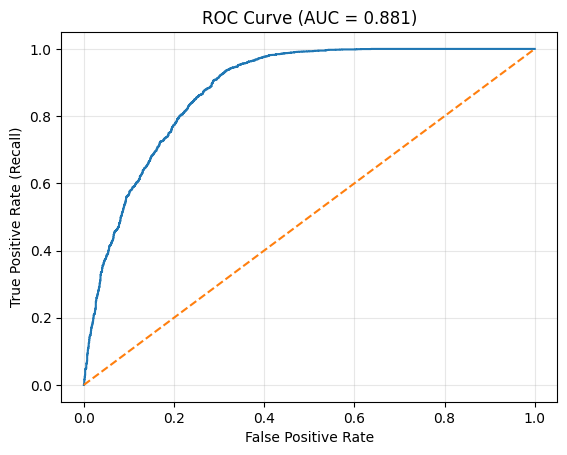

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title(f"ROC Curve (AUC = {auc:.3f})")
plt.grid(True, alpha=0.3)
plt.show()


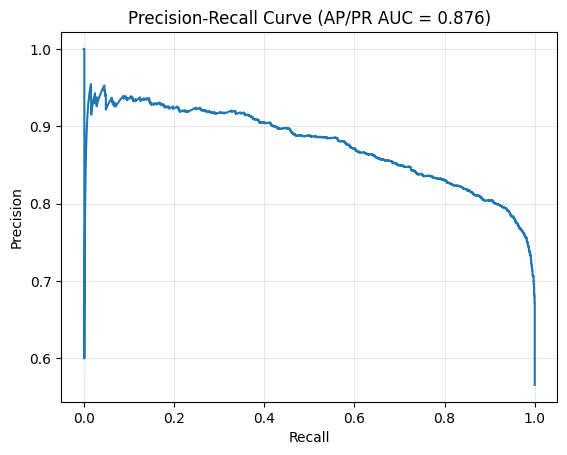

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP/PR AUC = {ap:.3f})")
plt.grid(True, alpha=0.3)
plt.show()


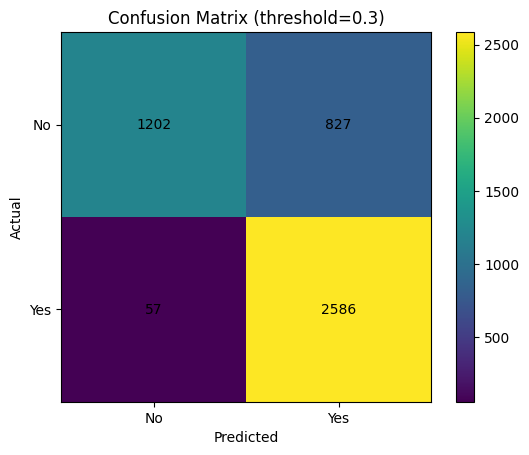

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

t = 0.3  # try 0.2, 0.3, 0.5 etc.
pred = (proba >= t).astype(int)
cm = confusion_matrix(y_test, pred)

plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix (threshold={t})")
plt.colorbar()
ticks = np.arange(2)
plt.xticks(ticks, ["No", "Yes"])
plt.yticks(ticks, ["No", "Yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

# write numbers on cells
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


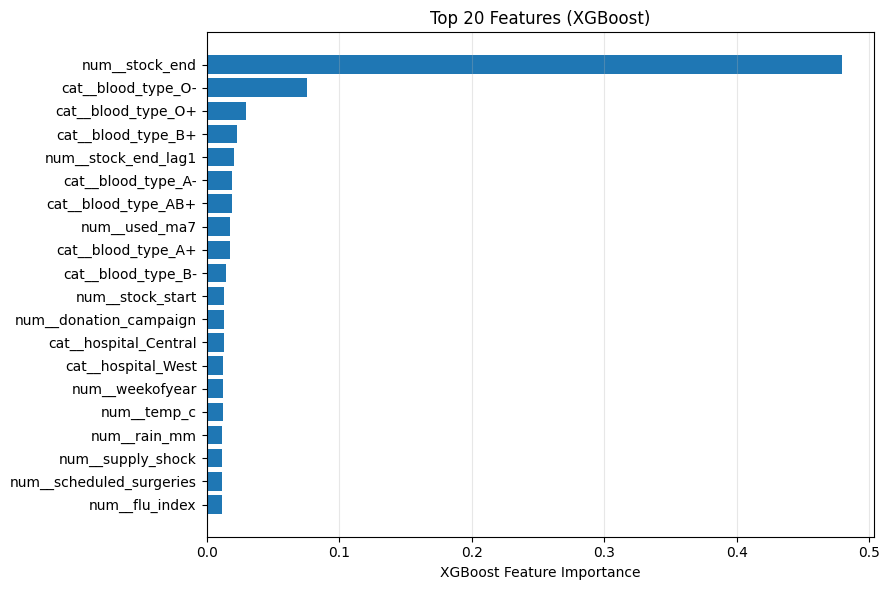

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

xgb_model = model_xgb.named_steps["xgb"]
feat_names = model_xgb.named_steps["prep"].get_feature_names_out()

imp = xgb_model.feature_importances_
N = 20
idx = np.argsort(imp)[-N:]

plt.figure(figsize=(9, 6))
plt.barh(np.array(feat_names)[idx], imp[idx])
plt.xlabel("XGBoost Feature Importance")
plt.title(f"Top {N} Features (XGBoost)")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


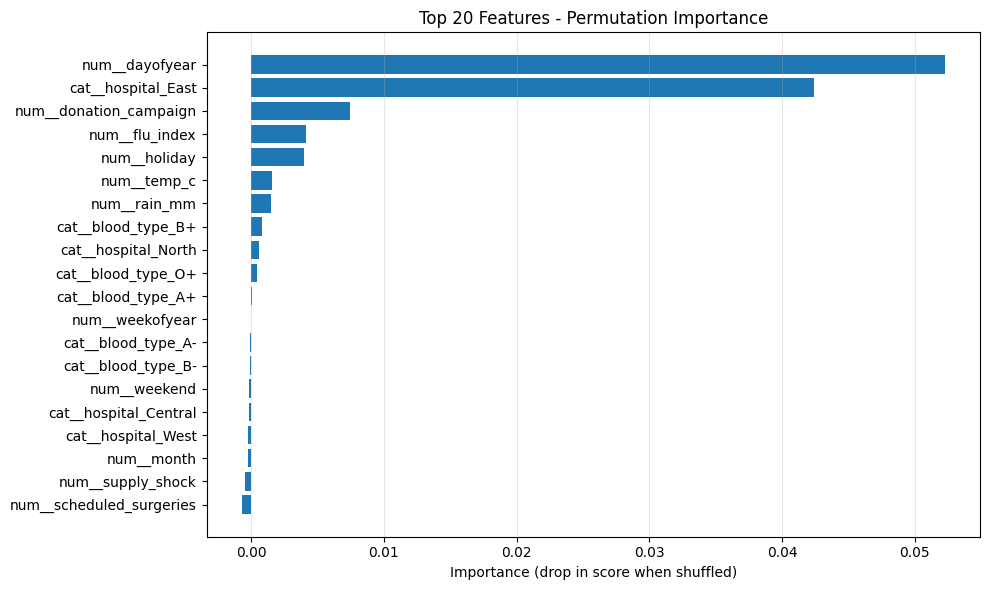

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# Make sure model is already fitted:
# model.fit(X_train, y_train)

feat_names = model.named_steps["prep"].get_feature_names_out()

perm = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="average_precision"   # or "roc_auc"
)

N = 20
idx = np.argsort(perm.importances_mean)[-N:]

plt.figure(figsize=(10, 6))
plt.barh(np.array(feat_names)[idx], perm.importances_mean[idx])
plt.xlabel("Importance (drop in score when shuffled)")
plt.title(f"Top {N} Features - Permutation Importance")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


In [4]:
import pandas as pd
import pathlib
base_dir = pathlib.Path.cwd().parent
DATA_PATH = base_dir / "datasets" / "synthetic_blood_transfusion.csv"
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "hospital", "blood_type"]).reset_index(drop=True)
df.head(5)

,date,hospital,dow,weekend,month,holiday,temp_c,rain_mm,flu_index,trauma_cases,...,blood_type,stock_start,units_collected,units_used,wastage,stock_end,critical_stock,stockout_next_day,heavy_demand,heavy_demand_next_day
0,2020-01-01,Central,6,1,1,1,17.537652,7.846072,0.443917,10,...,A+,67,3,11,1,58,0,0,1,0
1,2020-01-01,Central,6,1,1,1,17.537652,7.846072,0.443917,10,...,A-,56,1,6,1,50,0,0,0,1
2,2020-01-01,Central,6,1,1,1,17.537652,7.846072,0.443917,10,...,AB+,42,4,4,0,42,0,0,0,0
3,2020-01-01,Central,6,1,1,1,17.537652,7.846072,0.443917,10,...,AB-,48,0,3,0,45,0,0,0,0
4,2020-01-01,Central,6,1,1,1,17.537652,7.846072,0.443917,10,...,B+,69,4,8,0,65,0,0,0,0


In [5]:
import numpy as np
import pandas as pd

H = 60  # censor cap

df = df.sort_values(["hospital","blood_type","date"]).reset_index(drop=True)

def days_until_next_event(stockout_next_day: pd.Series, cap=60):
    # stockout_next_day is 0/1 for ONE group, ordered by date
    s = stockout_next_day.to_numpy()
    n = len(s)
    out = np.full(n, cap, dtype=float)

    next_idx = None
    for i in range(n-1, -1, -1):
        if s[i] == 1:
            next_idx = i
        if next_idx is not None and next_idx > i:
            out[i] = min(next_idx - i, cap)
        # else keep cap
    return out

df["days_until_stockout"] = (
    df.groupby(["hospital","blood_type"])["stockout_next_day"]
      .transform(lambda s: days_until_next_event(s, cap=H))
)


In [7]:
df.tail()
out_path = base_dir / "datasets" / "synthetic_blood_transfusion_with_target.csv"
df.to_csv(out_path, index=False)
print("Saved:", out_path)


Saved: d:\Projects\pios\ml-backend\datasets\synthetic_blood_transfusion_with_target.csv


In [9]:
import pandas as pd
import numpy as np
import pathlib

# ===== Load your dataset =====
base_dir = pathlib.Path.cwd().parent
DATA_PATH = base_dir / "datasets" / "synthetic_blood_transfusion.csv"

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

# IMPORTANT: group-time order (do NOT sort only by date)
df = df.sort_values(["hospital", "blood_type", "date"]).reset_index(drop=True)

print("Loaded:", df.shape)
print("Columns:", list(df.columns))

# =========================================================
# 1) Build regression target: days_until_stockout (censored)
# =========================================================
H = 60  # censor cap (change if you want)

def days_until_next_stockout(stockout_next_day: pd.Series, cap=60) -> np.ndarray:
    """
    For one (hospital, blood_type) series in date order.
    returns days until next day where stockout_next_day == 1 (within same group).
    If none in future -> cap (right-censored).
    """
    s = stockout_next_day.to_numpy().astype(int)
    n = len(s)
    out = np.full(n, cap, dtype=float)

    next_idx = None
    for i in range(n - 1, -1, -1):
        if s[i] == 1:
            next_idx = i
        if next_idx is not None and next_idx > i:
            out[i] = min(next_idx - i, cap)
    return out

df["days_until_stockout"] = (
    df.groupby(["hospital", "blood_type"])["stockout_next_day"]
      .transform(lambda s: days_until_next_stockout(s, cap=H))
)

print("Target created. Positive-ish (uncensored) rate:",
      (df["days_until_stockout"] < H).mean())

# ==========================================
# 2) Build engineered features (Case 2 file)
# ==========================================
feature_dfs = []

for (hosp, bt), g in df.groupby(["hospital", "blood_type"], sort=False):
    g = g.sort_values("date").reset_index(drop=True)

    # flow feature
    g["net_change"] = g["units_collected"] - g["units_used"] - g["wastage"]

    # lags
    for col in ["units_used", "units_collected", "stock_start"]:
        g[f"{col}_lag1"] = g[col].shift(1)
        g[f"{col}_lag7"] = g[col].shift(7)
        g[f"{col}_lag30"] = g[col].shift(30)

    # rollings (exclude today)
    for col in ["units_used", "units_collected"]:
        g[f"{col}_roll7_mean"]  = g[col].shift(1).rolling(7,  min_periods=1).mean()
        g[f"{col}_roll30_mean"] = g[col].shift(1).rolling(30, min_periods=1).mean()
        g[f"{col}_roll7_std"]   = g[col].shift(1).rolling(7,  min_periods=2).std()
        g[f"{col}_roll30_std"]  = g[col].shift(1).rolling(30, min_periods=2).std()

    # coverage + trend
    g["cover_days"] = g["stock_start"] / (g["units_used_roll7_mean"] + 1e-6)
    g["cover_days"] = g["cover_days"].clip(upper=365)

    g["usage_trend_7d"]  = g["units_used_roll7_mean"]  - g["units_used_lag7"]
    g["usage_trend_30d"] = g["units_used_roll30_mean"] - g["units_used_lag30"]

    # interactions
    g["surgeries_per_stock"] = g["scheduled_surgeries"] / (g["stock_start"] + 1)
    g["trauma_per_stock"]    = g["trauma_cases"] / (g["stock_start"] + 1)
    g["demand_pressure"]     = (g["scheduled_surgeries"] + g["trauma_cases"]) / (g["stock_start"] + 1)

    # recent stockout history (past only)
    g["stockout_lag1"]      = g["stockout_next_day"].shift(1)
    g["stockout_lag7"]      = g["stockout_next_day"].shift(7)
    g["stockout_roll7_sum"] = g["stockout_next_day"].shift(1).rolling(7, min_periods=1).sum()

    feature_dfs.append(g)

df_case2 = pd.concat(feature_dfs, ignore_index=True)

# Drop early rows that don't have lag1 (otherwise lots of NaNs)
df_case2 = df_case2.dropna(subset=["units_used_lag1", "units_collected_lag1"]).reset_index(drop=True)

print("After feature engineering:", df_case2.shape)

# ======================
# 3) Save Case 2 dataset
# ======================
OUT_PATH = base_dir / "datasets" / "synthetic_blood_transfusion_with_features.csv"
df_case2.to_csv(OUT_PATH, index=False)

print("Saved Case2 file to:", OUT_PATH)
print("Has target?", "days_until_stockout" in df_case2.columns)
print("Example engineered cols:",
      [c for c in df_case2.columns if "lag" in c][:10],
      [c for c in df_case2.columns if "roll" in c][:10])


Loaded: (46752, 23)
Columns: ['date', 'hospital', 'dow', 'weekend', 'month', 'holiday', 'temp_c', 'rain_mm', 'flu_index', 'trauma_cases', 'scheduled_surgeries', 'donation_campaign', 'supply_shock', 'blood_type', 'stock_start', 'units_collected', 'units_used', 'wastage', 'stock_end', 'critical_stock', 'stockout_next_day', 'heavy_demand', 'heavy_demand_next_day']
Target created. Positive-ish (uncensored) rate: 0.3535035934291581
After feature engineering: (46720, 51)
Saved Case2 file to: d:\Projects\pios\ml-backend\datasets\synthetic_blood_transfusion_with_features.csv
Has target? True
Example engineered cols: ['units_used_lag1', 'units_used_lag7', 'units_used_lag30', 'units_collected_lag1', 'units_collected_lag7', 'units_collected_lag30', 'stock_start_lag1', 'stock_start_lag7', 'stock_start_lag30', 'stockout_lag1'] ['units_used_roll7_mean', 'units_used_roll30_mean', 'units_used_roll7_std', 'units_used_roll30_std', 'units_collected_roll7_mean', 'units_collected_roll30_mean', 'units_colle

In [12]:
# ===== Load your dataset =====
base_dir = pathlib.Path.cwd().parent
DATA_PATH = base_dir / "datasets" / "synthetic_blood_transfusion_with_features.csv"

df_case2 = pd.read_csv(DATA_PATH)
df_case2.shape
df_case2.columns

Index(['date', 'hospital', 'dow', 'weekend', 'month', 'holiday', 'temp_c',
       'rain_mm', 'flu_index', 'trauma_cases', 'scheduled_surgeries',
       'donation_campaign', 'supply_shock', 'blood_type', 'stock_start',
       'units_collected', 'units_used', 'wastage', 'stock_end',
       'critical_stock', 'stockout_next_day', 'heavy_demand',
       'heavy_demand_next_day', 'days_until_stockout', 'net_change',
       'units_used_lag1', 'units_used_lag7', 'units_used_lag30',
       'units_collected_lag1', 'units_collected_lag7', 'units_collected_lag30',
       'stock_start_lag1', 'stock_start_lag7', 'stock_start_lag30',
       'units_used_roll7_mean', 'units_used_roll30_mean',
       'units_used_roll7_std', 'units_used_roll30_std',
       'units_collected_roll7_mean', 'units_collected_roll30_mean',
       'units_collected_roll7_std', 'units_collected_roll30_std', 'cover_days',
       'usage_trend_7d', 'usage_trend_30d', 'surgeries_per_stock',
       'trauma_per_stock', 'demand_pressure',

In [27]:
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import xgboost as xgb

# df_case2 = pd.read_csv("synthetic_blood_transfusion_case2.csv")  # if needed
df_case2["date"] = pd.to_datetime(df_case2["date"])

# ----- define target -----
y = df_case2["days_until_stockout"].astype(float)

# ----- define feature columns (drop leakage + target) -----
drop_cols = [
    "days_until_stockout",
    "date",
    "stock_end",              # avoid leakage
    "critical_stock",         # optional (can keep if you want)
    "heavy_demand_next_day"   # optional (not needed for this task)
]

feature_cols = [c for c in df_case2.columns if c not in drop_cols]

X = df_case2[feature_cols].copy()

# ----- encode categoricals -----
cat_cols = ["hospital", "blood_type", "dow", "month"]
encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    X[c] = le.fit_transform(X[c].astype(str))
    encoders[c] = le

# ----- time-based split (recommended) -----
df_case2 = df_case2.sort_values("date").reset_index(drop=True)
X = X.loc[df_case2.index]
y = y.loc[df_case2.index]

n = len(df_case2)
test_size = 0.15
val_size = 0.15

test_start = int(n * (1 - test_size))
val_start  = int(n * (1 - test_size - val_size))

X_train, y_train = X.iloc[:val_start], y.iloc[:val_start]
X_val,   y_val   = X.iloc[val_start:test_start], y.iloc[val_start:test_start]
X_test,  y_test  = X.iloc[test_start:], y.iloc[test_start:]

# ----- train regressor -----
reg_lgb = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

reg_lgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

# ----- eval -----
pred = reg_lgb.predict(X_test)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("MAE:", mae, "RMSE:", rmse)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003476 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4328
[LightGBM] [Info] Number of data points in the train set: 32703, number of used features: 46
[LightGBM] [Info] Start training from score 42.647769
MAE: 2.900363604338479 RMSE: 6.465375256707618


In [29]:
feature_importances = reg_lgb.feature_importances_
print("Feature importances:")
for f, imp in zip(feature_cols, feature_importances):
    print(f"{f}: {imp}")    
sorted_idx = np.argsort(feature_importances)[-20:]

Feature importances:
hospital: 191
dow: 2
weekend: 0
month: 296
holiday: 0
temp_c: 123
rain_mm: 17
flu_index: 109
trauma_cases: 13
scheduled_surgeries: 10
donation_campaign: 0
supply_shock: 0
blood_type: 273
stock_start: 118
units_collected: 15
units_used: 23
wastage: 7
stockout_next_day: 105
heavy_demand: 2
net_change: 152
units_used_lag1: 13
units_used_lag7: 6
units_used_lag30: 11
units_collected_lag1: 5
units_collected_lag7: 6
units_collected_lag30: 11
stock_start_lag1: 74
stock_start_lag7: 150
stock_start_lag30: 187
units_used_roll7_mean: 137
units_used_roll30_mean: 328
units_used_roll7_std: 79
units_used_roll30_std: 411
units_collected_roll7_mean: 40
units_collected_roll30_mean: 217
units_collected_roll7_std: 107
units_collected_roll30_std: 300
cover_days: 173
usage_trend_7d: 21
usage_trend_30d: 20
surgeries_per_stock: 34
trauma_per_stock: 43
demand_pressure: 57
stockout_lag1: 67
stockout_lag7: 3
stockout_roll7_sum: 34


In [30]:
import xgboost as xgb
print(xgb.__version__)


3.1.3


In [31]:
import numpy as np
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

# df_case2 already in memory
df_case2["date"] = pd.to_datetime(df_case2["date"])
df_case2 = df_case2.sort_values("date").reset_index(drop=True)

# ----- target -----
y = df_case2["days_until_stockout"].astype(float)

# ----- features -----
drop_cols = [
    "days_until_stockout",
    "date",
    "stock_end",            # avoid leakage
    "critical_stock",       # optional
    "heavy_demand_next_day" # optional
]
feature_cols = [c for c in df_case2.columns if c not in drop_cols]
X = df_case2[feature_cols].copy()

# ----- encode categoricals -----
cat_cols = ["hospital", "blood_type", "dow", "month"]
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    X[c] = le.fit_transform(X[c].astype(str))
    encoders[c] = le

# ----- time split -----
n = len(df_case2)
test_size = 0.15
val_size = 0.15
test_start = int(n * (1 - test_size))
val_start  = int(n * (1 - test_size - val_size))

X_train, y_train = X.iloc[:val_start], y.iloc[:val_start]
X_val,   y_val   = X.iloc[val_start:test_start], y.iloc[val_start:test_start]
X_test,  y_test  = X.iloc[test_start:], y.iloc[test_start:]

# ----- XGBoost regressor -----
reg = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=5000,          # let early stopping choose
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"          # fast CPU
)

reg.fit(X_train, y_train)  

pred = reg.predict(X_test)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("MAE:", mae, "RMSE:", rmse)



MAE: 3.1456060632676595 RMSE: 6.735698005832945


In [32]:
feature_importances = reg.feature_importances_
print("Feature importances:")
for f, imp in zip(feature_cols, feature_importances):
    print(f"{f}: {imp}")    

Feature importances:
hospital: 0.005347497295588255
dow: 0.0006026983028277755
weekend: 0.0006466600461862981
month: 0.005844877101480961
holiday: 0.0009954932611435652
temp_c: 0.0019233680795878172
rain_mm: 0.0008773952722549438
flu_index: 0.0024670581333339214
trauma_cases: 0.001033681444823742
scheduled_surgeries: 0.001032417407259345
donation_campaign: 0.0009886897169053555
supply_shock: 0.0011867034481838346
blood_type: 0.02377987653017044
stock_start: 0.04787379130721092
units_collected: 0.0012883732561022043
units_used: 0.002062167739495635
wastage: 0.0012146048247814178
stockout_next_day: 0.3571591377258301
heavy_demand: 0.0009049389627762139
net_change: 0.01219247281551361
units_used_lag1: 0.0011390201980248094
units_used_lag7: 0.001232372596859932
units_used_lag30: 0.0010001034243032336
units_collected_lag1: 0.0008584643364883959
units_collected_lag7: 0.001050575403496623
units_collected_lag30: 0.001135059748776257
stock_start_lag1: 0.01276722177863121
stock_start_lag7: 0.006

In [ ]:
print(feature_cols)
#with open("features.txt", "w") as f:
#    for c in feature_cols:
#        f.write(c + "\n")
len(feature_cols)


['hospital', 'dow', 'weekend', 'month', 'holiday', 'temp_c', 'rain_mm', 'flu_index', 'trauma_cases', 'scheduled_surgeries', 'donation_campaign', 'supply_shock', 'blood_type', 'stock_start', 'units_collected', 'units_used', 'wastage', 'stockout_next_day', 'heavy_demand', 'net_change', 'units_used_lag1', 'units_used_lag7', 'units_used_lag30', 'units_collected_lag1', 'units_collected_lag7', 'units_collected_lag30', 'stock_start_lag1', 'stock_start_lag7', 'stock_start_lag30', 'units_used_roll7_mean', 'units_used_roll30_mean', 'units_used_roll7_std', 'units_used_roll30_std', 'units_collected_roll7_mean', 'units_collected_roll30_mean', 'units_collected_roll7_std', 'units_collected_roll30_std', 'cover_days', 'usage_trend_7d', 'usage_trend_30d', 'surgeries_per_stock', 'trauma_per_stock', 'demand_pressure', 'stockout_lag1', 'stockout_lag7', 'stockout_roll7_sum']


46

In [36]:
from UniversalModelExporter import UniversalModelExporter

model_dir = pathlib.Path.cwd().parent
MODEL_PATH = model_dir / "models"

UniversalModelExporter.export_xgboost(
    model=reg,
    output_path=MODEL_PATH / "days_until_stockout_reg.pkl",
    description="how many days un",
    feature_names=feature_cols
)

📦 [XGBoost] Saved to d:\Projects\pios\ml-backend\models\days_until_stockout_reg.pkl
